# Figures

Generate figures for main text and SI

In [41]:
def safe_parse(val):
    try:
        if pd.isna(val): return None
    except (TypeError, ValueError): pass
    while isinstance(val, str):
        try: val = ast.literal_eval(val)
        except (ValueError, SyntaxError): break
    return val

In [42]:
import sys
from pathlib import Path
sys.path.append(str(Path(PATH TO PBSG)))

import pbsg
from pbsg.polymer import polymers_from_df
from pbsg.polymer.generators import smiles_from_graphs
from pbsg.ml import to_pyg
from pbsg.ml.pyg import architecture_onehot
from pbsg.polymer.parser import parse_smiles_list

In [43]:
import importlib
import scripts.fig3_cls
importlib.reload(scripts.fig3_cls)

<module 'scripts.fig3_cls' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Classifier/scripts/fig3_cls.py'>

In [4]:
%run scripts/fig3_cls.py

GINE (PBSG)
Saved: Figures/fig3a_roc_gine_pbsg.pdf
Saved: Figures/fig3b_pr_gine_pbsg.pdf
Saved: Figures/fig3c_cm_gine_pbsg.pdf
XGB (FP+pooled poly)
Saved: Figures/fig3a_roc_xgb_fp_pooled_poly.pdf
Saved: Figures/fig3b_pr_xgb_fp_pooled_poly.pdf
Saved: Figures/fig3c_cm_xgb_fp_pooled_poly.pdf
Saved: Figures/fig3d_subgroup_stereo.pdf
Saved: Figures/fig3e_subgroup_arch.pdf

All Figure 3 panels saved.


In [5]:
%run scripts/fig2_cls.py

Saved: Figures/fig2a_cv_heatmap_gnn.pdf
Saved: Figures/fig2a_cv_heatmap_classical.pdf

Both heatmaps saved.


In [6]:
%run scripts/fig2b_cls.py

Saved: Figures/fig2b_cv_barchart.pdf


In [7]:
%run scripts/fig2c_efficiency_scatter.py

Saved: Figures/fig2c_gnn_efficiency.pdf


In [44]:
import json
import numpy as np
import pandas as pd

In [45]:
df_cls=pd.read_csv('data_classifier.csv')

In [46]:
with open("random_stratified_splits_cls.json") as f:
    splits = json.load(f)

folds        = splits["folds"]
test_idx     = splits["test"]
all_idx      = np.arange(len(df_cls))
trainval_idx = np.setdiff1d(all_idx, test_idx)
print(f"trainval={len(trainval_idx)}  test={len(test_idx)}  folds={len(folds)}")

trainval=546  test=97  folds=5


In [11]:
import numpy as np

X_fp_RU        = np.load("Vectors/X_fp_RU.npy")

In [38]:
import importlib
import scripts.fig1_dataset_overview
importlib.reload(scripts.fig1_dataset_overview)

<module 'scripts.fig1_dataset_overview' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Classifier/scripts/fig1_dataset_overview.py'>

In [39]:
from scripts.fig1_dataset_overview import plot_dataset_composition, plot_label_distribution, plot_tsne

plot_dataset_composition(df_cls)
plot_label_distribution(df_cls, trainval_idx, test_idx)
plot_tsne(X_fp_RU, df_cls, trainval_idx, test_idx)


Saved: Figures/fig1b_dataset_composition.pdf
Saved: Figures/fig1c_label_distribution.pdf
  Running t-SNE (this takes ~1-2 minutes)...
Saved: Figures/fig1d_tsne.pdf


array([[ 27.425034, 141.17657 ],
       [ 26.226686, 152.31909 ],
       [ 27.425034, 141.17657 ],
       ...,
       [141.51614 , -15.650896],
       [197.66429 , -68.63202 ],
       [177.6256  , -62.79616 ]], dtype=float32)

In [13]:
import importlib
import scripts.fig1_split_validation

importlib.reload(scripts.fig1_split_validation)

<module 'scripts.fig1_split_validation' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML/Classifier/scripts/fig1_split_validation.py'>

In [14]:
from scripts.fig1_split_validation import plot_split_validation
plot_split_validation(df_cls, trainval_idx, test_idx)

Saved: Figures/fig1c_split_validation-2.pdf


In [22]:
import joblib
from dov import DomainOfValidity

In [25]:
dov=joblib.load("dov_cls.pkl")
# Score test set
result_df = dov.score_df(
    query_smiles = df_cls.iloc[test_idx]["repeat_units"].tolist(),
)

result_df['has_Tm']=df_cls['has_Tm']

print(result_df["in_domain_chem"].value_counts())
print(result_df["reliability"].value_counts())
print("\nOOD polymers:")
print(result_df[~result_df["in_domain_chem"]][["smiles","dov_score","reliability", "has_Tm"]])

in_domain_chem
True     91
False     6
Name: count, dtype: int64
reliability
High        85
Moderate     6
Low          5
Very low     1
Name: count, dtype: int64

OOD polymers:
                                               smiles  dov_score reliability  \
15  [*]C(=O)c1ccc(cc1)S(=O)(=O)c1ccc(cc1)C(=O)NCCC...     0.4485         Low   
33                          [*]C(C)(C1=CC=CC=C1)CC[*]     0.4003         Low   
37                                       [*]C(CC)C[*]     0.4968         Low   
43                                     [*]CC(C)([*])C     0.3636         Low   
64  [*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=...     0.3516         Low   
70                                    [*]C(C)(C)CC[*]     0.2775    Very low   

    has_Tm  
15   False  
33   False  
37    True  
43   False  
64   False  
70    True  


In [26]:
result_df[~result_df["in_domain_chem"]][["smiles","dov_score","reliability", "has_Tm"]]

,smiles,dov_score,reliability,has_Tm
15,[*]C(=O)c1ccc(cc1)S(=O)(=O)c1ccc(cc1)C(=O)NCCC...,0.4485,Low,False
33,[*]C(C)(C1=CC=CC=C1)CC[*],0.4003,Low,False
37,[*]C(CC)C[*],0.4968,Low,True
43,[*]CC(C)([*])C,0.3636,Low,False
64,[*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=...,0.3516,Low,False
70,[*]C(C)(C)CC[*],0.2775,Very low,True


In [27]:
with open("test_predictions-full.json") as f:
    test_results_reg = json.load(f)
print(test_results_reg.keys())

dict_keys(['gcn_pbsg', 'gcn_smiles', 'gcn_smiles_gl', 'gine_pbsg', 'gine_smiles', 'gine_smiles_gl', 'gatv2_pbsg', 'gatv2_smiles', 'gatv2_smiles_gl', 'lr_fp_pooled_ru', 'lr_fp_ru', 'lr_fp_pooled_poly', 'lr_fp_poly', 'rf_fp_pooled_ru', 'rf_fp_ru', 'rf_fp_pooled_poly', 'rf_fp_poly', 'xgb_fp_pooled_ru', 'xgb_fp_ru', 'xgb_fp_pooled_poly', 'xgb_fp_poly'])


In [28]:
print(f"df length: {len(df_cls)}")
print(f"test_idx range: {min(test_idx)} to {max(test_idx)}")
print(f"test_idx length: {len(test_idx)}")

df length: 643
test_idx range: 12 to 639
test_idx length: 97


In [29]:
y=np.load('Vectors/y.npy')

In [77]:
test_results.keys()

dict_keys(['gcn_pbsg', 'gcn_smiles', 'gcn_smiles_gl', 'gine_pbsg', 'gine_smiles', 'gine_smiles_gl', 'gatv2_pbsg', 'gatv2_smiles', 'gatv2_smiles_gl', 'lr_fp_pooled_ru', 'lr_fp_ru', 'lr_fp_pooled_poly', 'lr_fp_poly', 'rf_fp_pooled_ru', 'rf_fp_ru', 'rf_fp_pooled_poly', 'rf_fp_poly', 'xgb_fp_pooled_ru', 'xgb_fp_ru', 'xgb_fp_pooled_poly', 'xgb_fp_poly'])

In [ ]:
import json
import numpy as np
import pandas as pd
import joblib

# Load test results
with open("test_predictions-full.json") as f:
    test_results = json.load(f)

# Use xgb_poly (best classifier)
labels = np.array(test_results["xgb_fp_pooled_poly"]["labels"])
preds  = np.array(test_results["xgb_fp_pooled_poly"]["preds"])
probs  = np.array(test_results["xgb_fp_pooled_poly"]["probs"])
thresh = test_results["xgb_fp_pooled_poly"]["thresh"]

# Load DoV and score test set
dov_cls = joblib.load("dov_cls.pkl")

# Get test set from full dataframe
df_full = pd.read_csv("data_classifier.csv")
with open("random_stratified_splits_cls.json") as f:
    splits = json.load(f)
test_idx = splits["test"]

ru_list     = df_full.iloc[test_idx]["repeat_units"].tolist()
stereo_list = df_full.iloc[test_idx]["stereo_class"].tolist()

dov_scores, _, in_domain, _ = dov_cls.score(ru_list, stereo_list)
dov_scores = np.array(dov_scores)
in_domain  = np.array(in_domain)

# Build results dataframe
df_test = df_full.iloc[test_idx].reset_index(drop=True)
df_test["dov_score"]   = dov_scores
df_test["in_domain"]   = in_domain
df_test["true_has_Tm"] = labels
df_test["pred_has_Tm"] = preds
df_test["prob_has_Tm"] = probs.round(4)
df_test["correct"]     = (preds == labels)

# OOD polymers
df_ood = df_test[~df_test["in_domain"]].copy()
df_in  = df_test[df_test["in_domain"]].copy()

print(f"OOD test polymers: {len(df_ood)}")
print(f"In-domain test polymers: {len(df_in)}")
print()
print(df_ood[[
    "repeat_units", "stereo_class", "dov_score",
    "true_has_Tm", "pred_has_Tm", "prob_has_Tm", "correct"
]].sort_values("dov_score").to_string())

print(f"\nOOD misclassified:      {(~df_ood['correct']).sum()} / {len(df_ood)} "
      f"({(~df_ood['correct']).mean():.1%})")
print(f"In-domain misclassified: {(~df_in['correct']).sum()} / {len(df_in)} "
      f"({(~df_in['correct']).mean():.1%})")
print(f"Error rate ratio: {(~df_ood['correct']).mean() / (~df_in['correct']).mean():.1f}×")

OOD test polymers: 6
In-domain test polymers: 91

                                             repeat_units stereo_class  dov_score  true_has_Tm  pred_has_Tm  prob_has_Tm  correct
70                                        [*]C(C)(C)CC[*]      achiral   0.277534            1            0       0.6770    False
64   [*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=O)C=C1      achiral   0.351557            1            0       0.2813    False
43                                         [*]CC(C)([*])C      achiral   0.363636            0            0       0.5987     True
33                              [*]C(C)(C1=CC=CC=C1)CC[*]      atactic   0.400321            0            0       0.0077     True
15  [*]C(=O)c1ccc(cc1)S(=O)(=O)c1ccc(cc1)C(=O)NCCCCCCN[*]      achiral   0.448531            1            1       0.9640     True
37                                           [*]C(CC)C[*]    isotactic   0.496825            1            1       0.8120     True

OOD misclassified:      2 / 6 (33.3%)
I

In [79]:
import pandas as pd

# Clean up repeat units for display
df_ood_display = df_ood[[
    "repeat_units", "stereo_class", "dov_score",
    "prob_has_Tm", "pred_has_Tm", "true_has_Tm", "correct"
]].sort_values("dov_score").copy()

# Format columns
df_ood_display["dov_score"]   = df_ood_display["dov_score"].round(3)
df_ood_display["prob_has_Tm"] = df_ood_display["prob_has_Tm"].round(3)
df_ood_display["pred_has_Tm"] = df_ood_display["pred_has_Tm"].map({1: "Yes", 0: "No"})
df_ood_display["true_has_Tm"] = df_ood_display["true_has_Tm"].map({1: "Yes", 0: "No"})
df_ood_display["correct"]     = df_ood_display["correct"].map({True: "✓", False: "✗"})

df_ood_display.columns = [
    "Repeat Unit SMILES", "Stereo Class", "DoV Score",
    "P(has Tm)", "Predicted", "Actual", "Correct"
]

df_ood_display = df_ood_display.reset_index(drop=True)
df_ood_display.index = df_ood_display.index + 1  # 1-indexed

print(df_ood_display.to_string())
print()
print("For ChemDraw — SMILES list:")
for i, smi in enumerate(df_ood_display["Repeat Unit SMILES"], 1):
    print(f"  {i}. {smi}")

                                      Repeat Unit SMILES Stereo Class  DoV Score  P(has Tm) Predicted Actual Correct
1                                        [*]C(C)(C)CC[*]      achiral      0.278      0.677        No    Yes       ✗
2   [*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=O)C=C1      achiral      0.352      0.281        No    Yes       ✗
3                                         [*]CC(C)([*])C      achiral      0.364      0.599        No     No       ✓
4                              [*]C(C)(C1=CC=CC=C1)CC[*]      atactic      0.400      0.008        No     No       ✓
5  [*]C(=O)c1ccc(cc1)S(=O)(=O)c1ccc(cc1)C(=O)NCCCCCCN[*]      achiral      0.449      0.964       Yes    Yes       ✓
6                                           [*]C(CC)C[*]    isotactic      0.497      0.812       Yes    Yes       ✓

For ChemDraw — SMILES list:
  1. [*]C(C)(C)CC[*]
  2. [*]C1=CC=C(C(C2=CC=C(OC3=CC=C(O[*])C=C3)C=C2)=O)C=C1
  3. [*]CC(C)([*])C
  4. [*]C(C)(C1=CC=CC=C1)CC[*]
  5. [*]C(=O)c1ccc(cc1

In [80]:
from scripts.figs_dov import plot_dov_cls, average_precision_score
plot_dov_cls(dov, result_df, test_results_reg, best_model_key="xgb_fp_pooled_poly")

Saved: Figures/figS_dov_cls.pdf


In [81]:
in_domain = result_df["in_domain_chem"].values
labels    = np.array(test_results_reg["xgb_fp_pooled_poly"]["labels"])
probs     = np.array(test_results_reg["xgb_fp_pooled_poly"]["probs"])

print("In-domain (n=91):")
print(f"  AUPRC: {average_precision_score(labels[in_domain], probs[in_domain]):.3f}")

print("OOD (n=6):")
# Can't compute AUPRC on 6 samples reliably, show raw predictions instead
ood_idx = np.where(~in_domain)[0]
for i in ood_idx:
    print(f"  label={labels[i]}  prob={probs[i]:.3f}  correct={int(labels[i])==int(probs[i]>0.5)}")

In-domain (n=91):
  AUPRC: 0.980
OOD (n=6):
  label=1  prob=0.964  correct=True
  label=0  prob=0.008  correct=True
  label=1  prob=0.812  correct=True
  label=0  prob=0.599  correct=False
  label=1  prob=0.281  correct=False
  label=1  prob=0.677  correct=True


In [82]:
from scripts.figs_cv_boxplots import plot_cv_boxplots_cls
plot_cv_boxplots_cls()


Saved: ./figS_cv_boxplots_cls.pdf


In [83]:
import importlib
import scripts.figs_learning_curves
importlib.reload(scripts.figs_learning_curves)

<module 'scripts.figs_learning_curves' from '/Users/xgv7306/Library/CloudStorage/OneDrive-NorthwesternUniversity/northwestern/2-PolyID:Dora/polymer_melting_temp_ML_clean/Classifier/scripts/figs_learning_curves.py'>

In [84]:
from scripts.figs_learning_curves import plot_learning_curves_cls
plot_learning_curves_cls()

Saved: Figures/figS_learning_curve_cls.pdf


In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("test_results-full.csv")

In [5]:
import matplotlib.pyplot as plt

Saved — Simple: | GNN: 


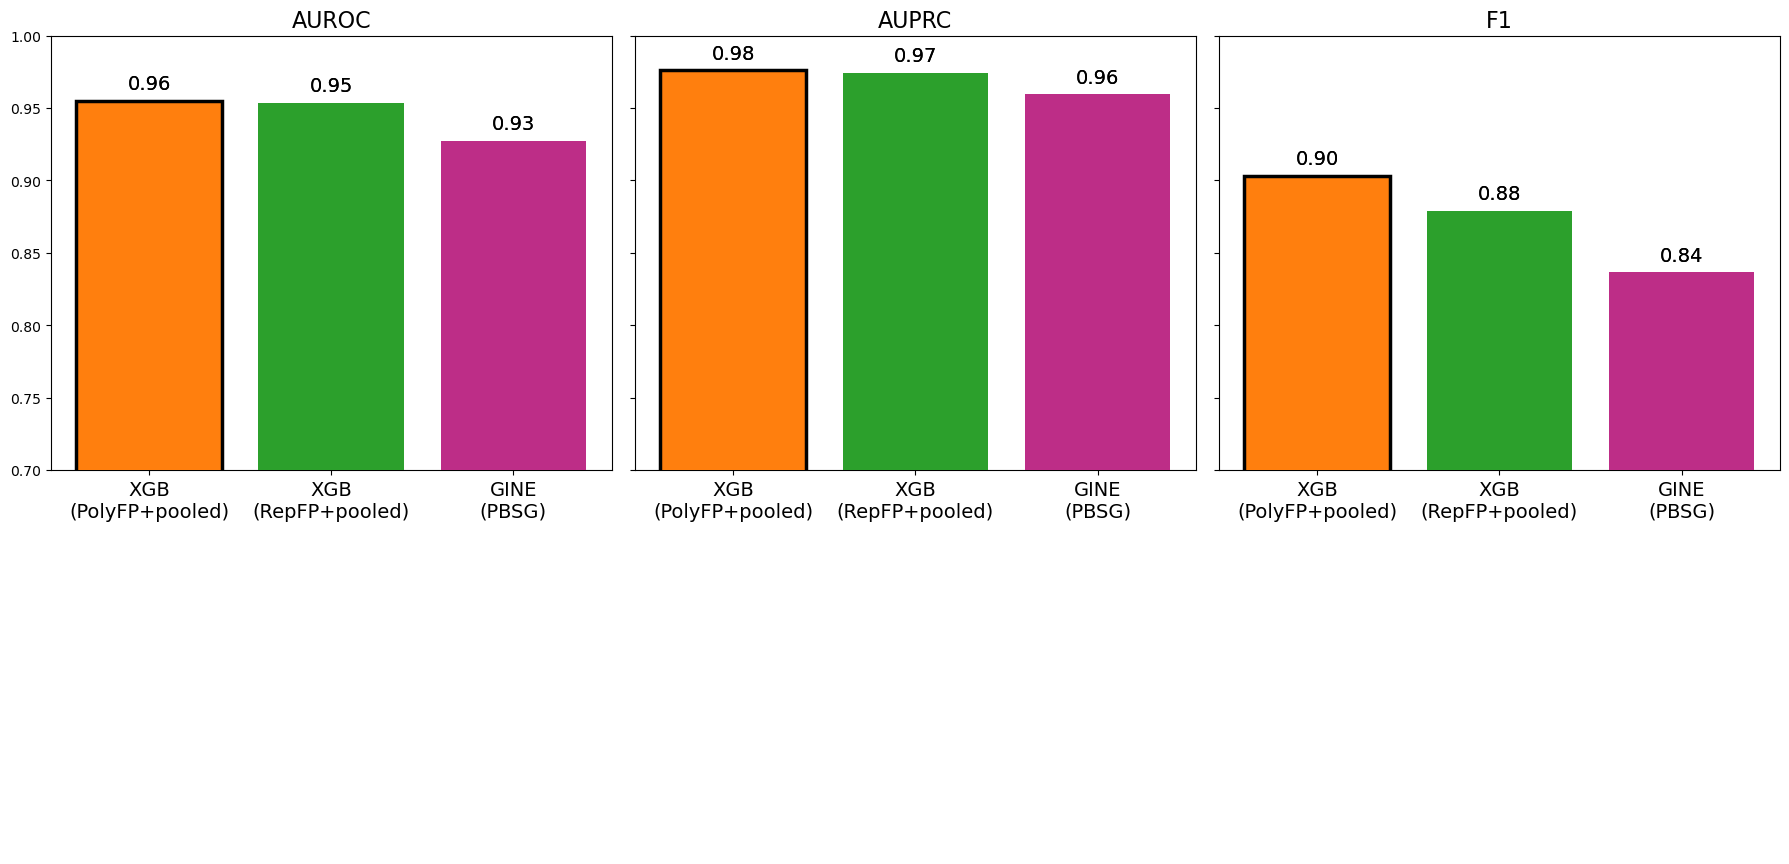

In [23]:
# --- pull best model row from each df ---
# simple: best AUPRC → XGB (PolyFP+pooled)
gine_pbsg_row = df.loc[df["name"] == "GINE (PBSG)"].iloc[0]
gatv2_pbsg_row = df.loc[df["name"] == "GATv2 (PBSG)"].iloc[0]
xgb_ru_row = df.loc[df["name"] == "XGB (FP+pooled RU)"].iloc[0]
xgb_poly_row = df.loc[df["name"] == "XGB (FP+pooled poly)"].iloc[0]
xgb_poly_simple_row = df.loc[df["name"] == "XGB (FP poly)"].iloc[0]


gine_pbsg_name="GINE (PBSG)"
gatv2_pbsg_name="GATv2 (PBSG)"
xgb_ru_name =  "XGB (RepFP+pooled)" 
xgb_poly_name =  "XGB (PolyFP+pooled)" 
xgb_poly_simple_name = "XGB (RepFP+pooled)"


# colors consistent with earlier plots
simple_color = "#ff7f0e"   
simple_dec_color= "#2ca02c" 
gnn_color    = "#BD2D87"   # PBSG purple

fig, axes = plt.subplots(1, 3, figsize=(18, 15), sharey=True)

for ax, (metric, label, lower_better) in zip(axes, [
    ("AUROC", "AUROC",        False),
    ("AUPRC",  "AUPRC",  False),
    ("Macro F1", "F1", False)
]):
    simple_val = xgb_poly_row[metric]
    simple_val_dec = xgb_ru_row[metric]
    gnn_val    = gine_pbsg_row[metric]
    gnn_val_dec = gatv2_pbsg_row[metric]

    bars = ax.bar(
        [0, 1, 2],
        [simple_val, simple_val_dec, gnn_val],
        width=0.8,
        color=[simple_color, simple_dec_color, gnn_color],
        zorder=3,
    )

    # best-of-two highlight
    overall_best = (min if lower_better else max)([simple_val, simple_val_dec, gnn_val])
    for bar, val in zip(bars, [simple_val, simple_val_dec, gnn_val]):
        if val == overall_best:
            bar.set_edgecolor("black" if val == simple_val else "black")
            bar.set_linewidth(2.5)
            # ax.text(bar.get_x() + bar.get_width() / 2,
            #         val + (0.005 if not lower_better else 0.3),
            #         "★", ha="center", va="bottom", fontsize=11, color="darkorange")

    # # delta: GNN vs simple
    # gain  = gnn_val - simple_val
    # sign  = "+" if gain >= 0 else ""
    # good  = (gain < 0 and lower_better) or (gain > 0 and not lower_better)
    # ypos  = gnn_val + (0.005 if not lower_better else 0.5)
    # ax.text(1, ypos, f"{sign}{gain:.2f}",
    #         ha="center", va="bottom", fontsize=8,
    #         color="darkgreen" if good else "darkred")

    # value labels inside bars
    for bar, val in zip(bars, [simple_val, gnn_val]):
        fmt = f"{val:.3f}" if metric == "r2" else f"{val:.2f}"
        ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            fmt, ha="center", va="center",
            fontsize=9, color="white", fontweight="bold")
        # value above bar
        for bar, val in zip(bars, [simple_val, simple_val_dec, gnn_val]):
            ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=14, color="black")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([xgb_poly_name.replace(" (", "\n("), xgb_poly_simple_name.replace(" (", "\n("),
                        gine_pbsg_name.replace(" (", "\n(")], fontsize=14)
    ax.set_title(label, fontsize=16)
    ax.spines[["top", "right"]].set_visible(True)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    if metric == "r2":
        ax.set_ylabel("Score (test)")

    pad = abs(simple_val - gnn_val) * 0.5
    ax.set_ylim(0.7, 1.0)
    #ax.set_ylim(0, 1.0)
    ax.grid(False)

# plt.suptitle(f"Best Simple Model vs Best GNN",
#              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("best_simple_vs_best_gnn.png", dpi=150, bbox_inches="tight")
print(f"Saved — Simple: | GNN: ")

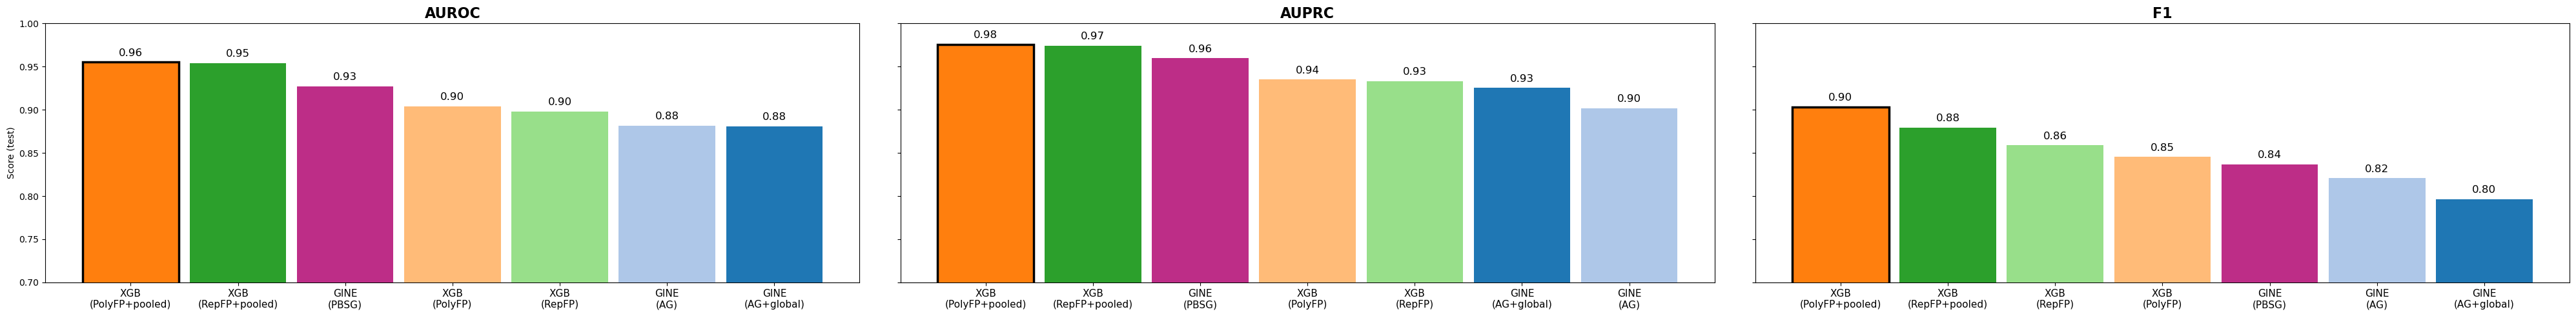

Saved.


In [27]:
# --- pull best model row from each df ---
gine_pbsg_row     = df.loc[df["name"] == "GINE (PBSG)"].iloc[0]
gine_ag_row       = df.loc[df["name"] == "GINE (SMILES)"].iloc[0]
gine_ag_plus_row  = df.loc[df["name"] == "GINE (SMILES+global)"].iloc[0]
xgb_ru_row        = df.loc[df["name"] == "XGB (FP+pooled RU)"].iloc[0]
xgb_ru_simple_row = df.loc[df["name"] == "XGB (FP RU)"].iloc[0]
xgb_poly_row      = df.loc[df["name"] == "XGB (FP+pooled poly)"].iloc[0]
xgb_poly_simple_row = df.loc[df["name"] == "XGB (FP poly)"].iloc[0]

# Single source of truth: (row, display label, color).
# Keeping this as one list means label/color/row can never drift apart again.
MODELS = [
    (xgb_poly_row,        "XGB\n(PolyFP+pooled)", "#ff7f0e"),
    (xgb_poly_simple_row, "XGB\n(PolyFP)",         "#ffbb78"),
    (xgb_ru_row,          "XGB\n(RepFP+pooled)",   "#2ca02c"),
    (xgb_ru_simple_row,   "XGB\n(RepFP)",          "#98df8a"),
    (gine_pbsg_row,       "GINE\n(PBSG)",          "#BD2D87"),
    (gine_ag_row,         "GINE\n(AG)",        "#aec7e8"),
    (gine_ag_plus_row,    "GINE\n(AG+global)", "#1f77b4"),
]

fig, axes = plt.subplots(1, 3, figsize=(40, 5), sharey=True)  # 15 tall was likely a typo

for ax, (metric, label) in zip(axes, [
    ("AUROC", "AUROC"),
    ("AUPRC", "AUPRC"),
    ("Macro F1", "F1"),
]):
    # sort this panel's bars by score, descending (higher is better for all 3 metrics)
    ranked = sorted(MODELS, key=lambda m: m[0][metric], reverse=True)
    labels_sorted = [m[1] for m in ranked]
    values_sorted = [m[0][metric] for m in ranked]
    colors_sorted = [m[2] for m in ranked]

    x = range(len(ranked))
    bars = ax.bar(x, values_sorted, width=0.9, color=colors_sorted, zorder=3)

    best_val = max(values_sorted)
    for bar, val in zip(bars, values_sorted):
        if val == best_val:
            bar.set_edgecolor("black")
            bar.set_linewidth(2.5)
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=12, color="black")

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels_sorted, fontsize=11)
    ax.set_title(label, fontsize=16, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(True)
    ax.set_ylim(0.7, 1.0)
    ax.grid(False)

axes[0].set_ylabel("Score (test)")

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
plt.savefig("full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

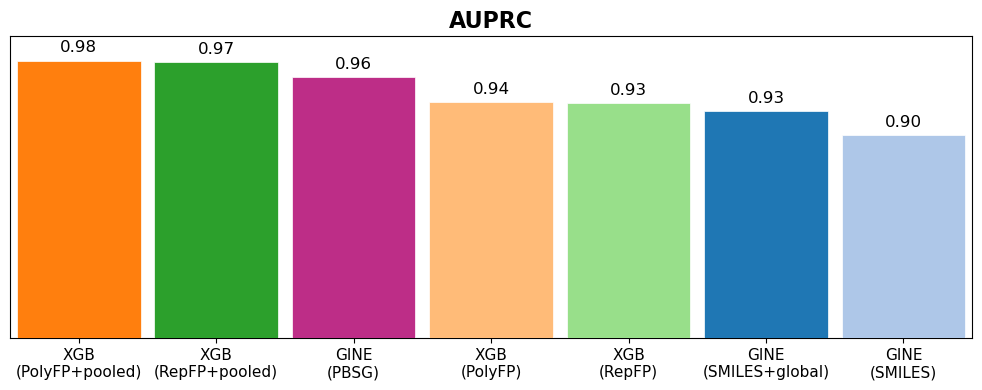

Saved.


In [38]:
# --- pull best model row from each df ---
gine_pbsg_row     = df.loc[df["name"] == "GINE (PBSG)"].iloc[0]
gine_ag_row       = df.loc[df["name"] == "GINE (SMILES)"].iloc[0]
gine_ag_plus_row  = df.loc[df["name"] == "GINE (SMILES+global)"].iloc[0]
xgb_ru_row        = df.loc[df["name"] == "XGB (FP+pooled RU)"].iloc[0]
xgb_ru_simple_row = df.loc[df["name"] == "XGB (FP RU)"].iloc[0]
xgb_poly_row      = df.loc[df["name"] == "XGB (FP+pooled poly)"].iloc[0]
xgb_poly_simple_row = df.loc[df["name"] == "XGB (FP poly)"].iloc[0]

# Single source of truth: (row, display label, color)
MODELS = [
    (xgb_poly_row,        "XGB\n(PolyFP+pooled)", "#ff7f0e"),
    (xgb_poly_simple_row, "XGB\n(PolyFP)",         "#ffbb78"),
    (xgb_ru_row,          "XGB\n(RepFP+pooled)",   "#2ca02c"),
    (xgb_ru_simple_row,   "XGB\n(RepFP)",          "#98df8a"),
    (gine_pbsg_row,       "GINE\n(PBSG)",          "#BD2D87"),
    (gine_ag_row,         "GINE\n(SMILES)",        "#aec7e8"),
    (gine_ag_plus_row,    "GINE\n(SMILES+global)", "#1f77b4"),
]

metric = "AUPRC"

ranked = sorted(MODELS, key=lambda m: m[0][metric], reverse=True)
labels_sorted = [m[1] for m in ranked]
values_sorted = [m[0][metric] for m in ranked]
colors_sorted = [m[2] for m in ranked]

fig, ax = plt.subplots(figsize=(10, 4))

x = range(len(ranked))
bars = ax.bar(x, values_sorted, width=0.9, color=colors_sorted,
               zorder=3, edgecolor="white", linewidth=0.5)

best_val = max(values_sorted)
for bar, val in zip(bars, values_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.2f}", ha="center", va="bottom", fontsize=12, color="black")

ax.set_xticks(list(x))
ax.set_xticklabels(labels_sorted, fontsize=11)
ax.set_title("AUPRC", fontsize=16, fontweight="bold")
ax.set_xlim(-0.5, len(x) - 0.5)  
#ax.set_ylabel("Score (test)")
ax.spines[["top", "right"]].set_visible(True)
ax.set_ylim(0.7, 1.0)
ax.set_yticks([])
ax.grid(False)

plt.tight_layout()
plt.savefig("auprc_only.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")